In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving voltage_stability_features.csv to voltage_stability_features.csv


In [ ]:
df = pd.read_csv('voltage_stability_features.csv')
df.head()

,Bus ID,Voltage Magnitude,Voltage Angle,freq_hz,Load Factor,Line Outage,Stability Label,label_numeric,voltage_deviation,stress_index
0,0,1.030957,40.330800,50.002858,0.6,0,STABLE,0,0.030957,0.018574
1,1,1.014978,58.253833,50.009634,0.6,0,STABLE,0,0.014978,0.008987
2,2,0.971241,52.192754,49.991081,0.6,0,STABLE,0,0.028759,0.017256
3,3,0.922611,40.375760,49.978707,0.6,0,STABLE,0,0.077389,0.046433
4,4,0.915772,32.559313,50.001585,0.6,0,STABLE,0,0.084228,0.050537


In [ ]:
df = df.copy()

df['is_outage'] = (df['Line Outage'] != -1).astype(int)

df = df.drop(['freq_hz', 'Line Outage', 'label_numeric'], axis=1)

df = df.dropna()

print(df.columns.tolist())
print(df.shape)
print(df['Stability Label'].value_counts())

['Bus ID', 'Voltage Magnitude', 'Voltage Angle', 'Load Factor', 'Stability Label', 'voltage_deviation', 'stress_index', 'is_outage']
(18149, 8)
Stability Label
STABLE      16286
WARNING      1439
UNSTABLE      424
Name: count, dtype: int64


In [ ]:
X = df.drop(['Stability Label'], axis=1)
y = df['Stability Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("\nTrain label distribution:")
print(y_train.value_counts())

Training size: (14519, 7)
Testing size: (3630, 7)

Train label distribution:
Stability Label
STABLE      13029
WARNING      1151
UNSTABLE      339
Name: count, dtype: int64


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print('=== Random Forest Results ===')
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest Results ===
              precision    recall  f1-score   support

      STABLE       0.98      0.99      0.99      3257
    UNSTABLE       0.48      0.41      0.44        85
     WARNING       0.76      0.74      0.75       288

    accuracy                           0.96      3630
   macro avg       0.74      0.71      0.73      3630
weighted avg       0.95      0.96      0.96      3630

[[3222   11   24]
 [   6   35   44]
 [  47   27  214]]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

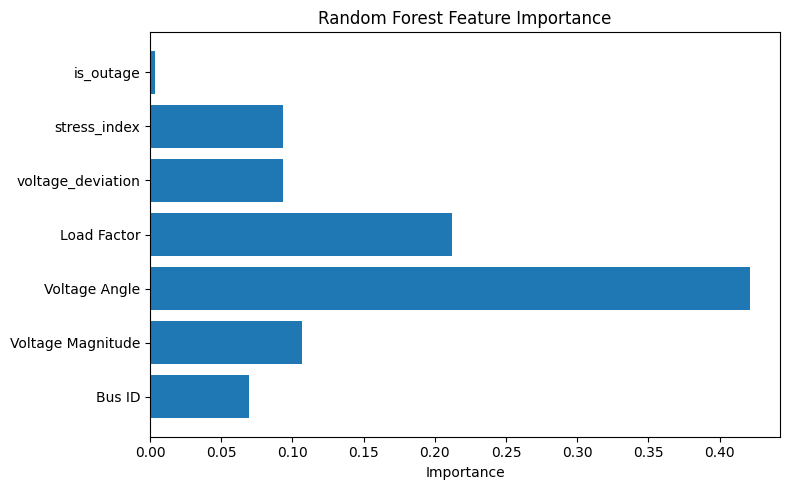

In [ ]:
feature_names = X_train.columns.tolist()
importances = rf_model.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances)
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=3,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train_enc)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb_labels = le.inverse_transform(y_pred_xgb)

print('=== XGBoost Results ===')
print(classification_report(y_test, y_pred_xgb_labels))
print(confusion_matrix(y_test, y_pred_xgb_labels))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:16:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost Results ===
              precision    recall  f1-score   support

      STABLE       0.99      0.99      0.99      3257
    UNSTABLE       0.49      0.42      0.46        85
     WARNING       0.79      0.75      0.77       288

    accuracy                           0.96      3630
   macro avg       0.76      0.72      0.74      3630
weighted avg       0.96      0.96      0.96      3630

[[3235    5   17]
 [   7   36   42]
 [  39   32  217]]


In [ ]:
from google.colab import files

df.to_csv('voltage_stability_final.csv', index=False)
files.download('voltage_stability_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>